# Visual Product Validation API Experimental Evaluation Notebook

Este notebook centraliza el proceso completo de evaluación experimental del proyecto de validación visual de productos.

El objetivo es:

- Consumir la API desarrollada en FastAPI.
- Evaluar automáticamente casos del dataset.
- Consolidar métricas de desempeño.
- Analizar el comportamiento del sistema.
- Visualizar similitudes entre imágenes mediante heatmaps.
- Identificar imágenes inconsistentes (`flagged_images`).
- Generar resultados reproducibles para el reporte del proyecto.

El notebook funciona como una interfaz experimental para analizar el desempeño del pipeline completo de visión por computadora.

In [1]:
import os
import json
import requests
import numpy as np
import pandas as pd

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as patches

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

plt.rcParams["figure.figsize"] = (8, 6)

# Configuración General

En esta sección se configuran:

- URL de la API.
- Directorios del dataset.
- Directorios de resultados.
- Parámetros generales de evaluación.

In [2]:
API_URL = "http://127.0.0.1:8081/validate-product-images"

DATASET_DIR = Path("images")

REPORTS_DIR = Path("reports")

REPORTS_DIR.mkdir(exist_ok=True)

MAX_CASES = None

print("Dataset exists:", DATASET_DIR.exists())
print("Reports exists:", REPORTS_DIR.exists())

Dataset exists: True
Reports exists: True


In [3]:
case_dirs = sorted([
    p for p in DATASET_DIR.iterdir()
    if p.is_dir()
])

print(f"Total de casos encontrados: {len(case_dirs)}")

Total de casos encontrados: 119


In [4]:
dataset_cases = []

for case_dir in case_dirs:

    labels_path = case_dir / "labels.json"

    if not labels_path.exists():
        print(f"Sin labels.json: {case_dir.name}")
        continue

    with open(labels_path, "r", encoding="utf-8") as f:
        labels_data = json.load(f)

    dataset_cases.append({
        "case_id": case_dir.name,
        "case_path": case_dir,
        "labels": labels_data
    })

print(f"Casos válidos cargados: {len(dataset_cases)}")

Sin labels.json: _backup_before_prepare
Casos válidos cargados: 118


# Evaluación Automática del Dataset

En esta etapa se ejecuta el pipeline completo sobre todos los casos del dataset.

Para cada caso se almacenan:

- Estado esperado.
- Estado predicho.
- Scores principales.
- Imágenes marcadas como inconsistentes.
- Matriz de similitud.

In [5]:
def call_validation_api(case_path, product_id="test-product"):

    image_files = sorted([
        p for p in case_path.iterdir()
        if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ])

    if len(image_files) < 6 or len(image_files) > 10:
        raise ValueError(
            f"{case_path.name} tiene {len(image_files)} imágenes. "
            "La API requiere entre 6 y 10."
        )

    files = []

    opened_files = []

    try:

        for img_path in image_files:

            f = open(img_path, "rb")

            opened_files.append(f)

            files.append(
                (
                    "images",
                    (
                        img_path.name,
                        f,
                        "image/jpeg"
                    )
                )
            )

        response = requests.post(
            API_URL,
            data={"product_id": product_id},
            files=files,
            timeout=120
        )

        response.raise_for_status()

        return response.json()

    finally:

        for f in opened_files:
            f.close()

# Consolidación de Resultados

Los resultados obtenidos se convierten en un DataFrame para facilitar análisis estadístico y visualización.

In [6]:
test_case = dataset_cases[0]

print("Caso seleccionado:")
print(test_case["case_id"])

Caso seleccionado:
1


In [ ]:
single_result = call_validation_api(
    test_case["case_path"]
)

print(single_result.keys())

dict_keys(['product_id', 'image_count', 'status', 'scores', 'note', 'thresholds', 'view_types', 'flagged_images', 'quality_warnings', 'dominant_colors', 'garment_type_estimates', 'image_debug', 'crop_debug_urls', 'pairwise_similarity_matrix', 'condition_estimate'])


In [8]:
single_result

{'product_id': 'test-product',
 'image_count': 6,
 'status': 'inconsistent',
 'scores': {'raw_consistency_score': 0.5728,
  'main_view_score': 0.6801,
  'detail_support_score': 0.8059,
  'color_consistency_score': 0.9008,
  'robust_consistency_score': 0.7448,
  'low_confidence_reason': None},
 'note': 'This is an MVP compatibility score using generic pretrained embeddings. It should be calibrated with real ecommerce image datasets before production use.',
 'thresholds': {'consistent': 0.7,
  'needs_review': 0.5,
  'main_view_low_similarity': 0.45,
  'main_view_severe_similarity': 0.35,
  'strong_color_mismatch': 0.55},
 'view_types': [{'image_index': 0,
   'view_type': 'detail_label',
   'confidence': 0.74,
   'note': 'Heuristic MVP estimate'},
  {'image_index': 1,
   'view_type': 'main_front',
   'confidence': 0.72,
   'note': 'Heuristic MVP estimate'},
  {'image_index': 2,
   'view_type': 'main_back',
   'confidence': 0.72,
   'note': 'Heuristic MVP estimate'},
  {'image_index': 3,
 

# Accuracy General del Sistema

Se calcula el porcentaje de casos donde el estado predicho coincide exactamente con el esperado.

In [9]:
evaluation_results = []

for idx, case in enumerate(dataset_cases):

    if MAX_CASES and idx >= MAX_CASES:
        break

    case_id = case["case_id"]

    case_path = case["case_path"]

    labels = case["labels"]

    expected_status = labels.get("expected_status")

    print(f"Evaluando caso: {case_id}")

    try:

        result = call_validation_api(case_path)

        evaluation_results.append({
            "case_id": case_id,
            "expected_status": expected_status,
            "predicted_status": result.get("status"),
            "robust_score": result.get("scores", {}).get("robust_consistency_score"),
            "raw_score": result.get("scores", {}).get("raw_consistency_score"),
            "main_view_score": result.get("scores", {}).get("main_view_score"),
            "color_score": result.get("scores", {}).get("color_consistency_score"),
            "flagged_images": result.get("flagged_images", []),
            "pairwise_matrix": result.get("pairwise_similarity_matrix"),
            "full_response": result
        })

    except Exception as e:

        print(f"Error en caso {case_id}: {e}")

Evaluando caso: 1
Evaluando caso: 10
Error en caso 10: 10 tiene 5 imágenes. La API requiere entre 6 y 10.
Evaluando caso: 100
Evaluando caso: 101
Evaluando caso: 103
Evaluando caso: 104
Evaluando caso: 105
Evaluando caso: 106
Evaluando caso: 107
Evaluando caso: 108
Evaluando caso: 109
Evaluando caso: 11
Evaluando caso: 110
Evaluando caso: 111
Evaluando caso: 112
Evaluando caso: 113
Evaluando caso: 114
Evaluando caso: 115
Evaluando caso: 116
Evaluando caso: 117
Evaluando caso: 118
Evaluando caso: 119
Evaluando caso: 12
Evaluando caso: 120
Evaluando caso: 13
Evaluando caso: 14
Evaluando caso: 15
Evaluando caso: 16
Error en caso 16: 16 tiene 5 imágenes. La API requiere entre 6 y 10.
Evaluando caso: 17
Evaluando caso: 18
Evaluando caso: 19
Evaluando caso: 2
Evaluando caso: 20
Evaluando caso: 21
Evaluando caso: 22
Evaluando caso: 23
Evaluando caso: 24
Evaluando caso: 25
Evaluando caso: 26
Evaluando caso: 27
Evaluando caso: 28
Evaluando caso: 29
Error en caso 29: 29 tiene 5 imágenes. La API 

# Distribución de Predicciones

Esta gráfica muestra la distribución de estados generados por el sistema.

In [10]:
results_df = pd.DataFrame(evaluation_results)

results_df.head()

,case_id,expected_status,predicted_status,robust_score,raw_score,main_view_score,color_score,flagged_images,pairwise_matrix,full_response
0,1,consistent,inconsistent,0.7448,0.5728,0.6801,0.9008,"[{'image_index': 5, 'filename': 'main_front_fl...","[[1.0, 0.8059, 0.5802, 0.5975, 0.7247, 0.2795]...","{'product_id': 'test-product', 'image_count': ..."
1,100,inconsistent,needs_review,0.7239,0.5045,0.6574,0.9457,[],"[[1.0, 0.6102, 0.6101, 0.447, 0.3921, 0.7896],...","{'product_id': 'test-product', 'image_count': ..."
2,101,inconsistent,inconsistent,0.5846,0.5586,0.5288,0.7176,"[{'image_index': 3, 'filename': '04_blue_front...","[[1.0, 0.6995, 0.6011, 0.5482, 0.4603, 0.4394]...","{'product_id': 'test-product', 'image_count': ..."
3,103,inconsistent,needs_review,0.7093,0.5863,0.6751,0.8198,[],"[[1.0, 0.519, 0.7826, 0.7566, 0.4074, 0.6678],...","{'product_id': 'test-product', 'image_count': ..."
4,104,inconsistent,inconsistent,0.6540,0.5557,0.6914,0.5721,"[{'image_index': 0, 'filename': '00_orange_fro...","[[1.0, 0.5765, 0.5483, 0.3281, 0.6914, 0.4886]...","{'product_id': 'test-product', 'image_count': ..."


In [11]:
accuracy = (
    results_df["expected_status"] ==
    results_df["predicted_status"]
).mean()

print(f"Exact Match Accuracy: {accuracy:.2%}")

Exact Match Accuracy: 68.75%


# Matriz de Confusión

La matriz de confusión permite observar cómo se comporta el sistema frente a cada categoría esperada.

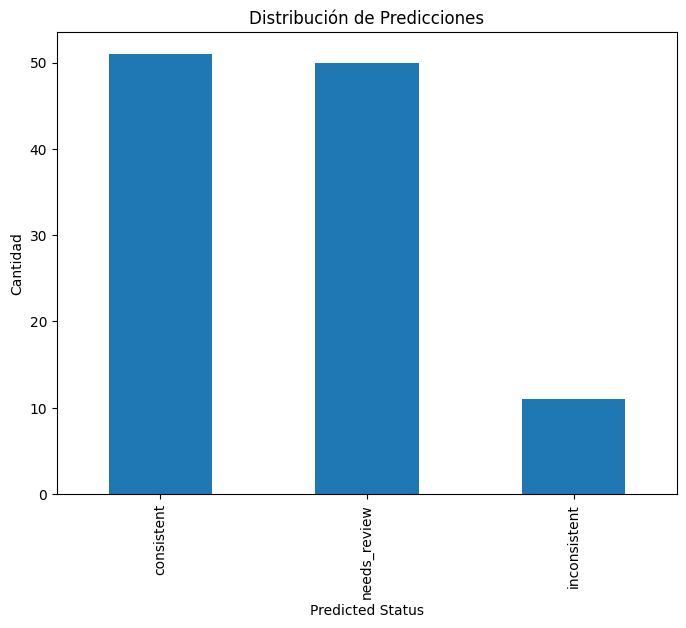

In [12]:
results_df["predicted_status"].value_counts().plot(kind="bar")

plt.title("Distribución de Predicciones")

plt.xlabel("Predicted Status")

plt.ylabel("Cantidad")

plt.show()

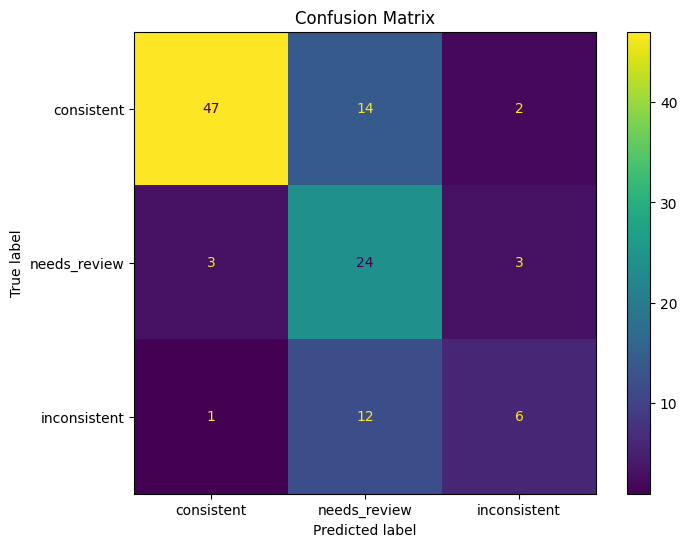

In [13]:
cm = confusion_matrix(
    results_df["expected_status"],
    results_df["predicted_status"],
    labels=["consistent", "needs_review", "inconsistent"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["consistent", "needs_review", "inconsistent"]
)

disp.plot()

plt.title("Confusion Matrix")

plt.show()

# Distribución del Robust Consistency Score

El `robust_consistency_score` representa la métrica principal utilizada por el sistema para tomar decisiones finales.

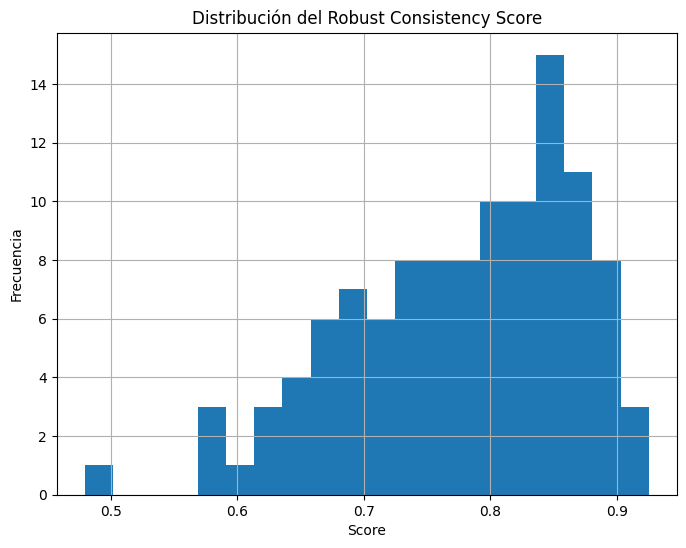

In [14]:
results_df["robust_score"].hist(bins=20)

plt.title("Distribución del Robust Consistency Score")

plt.xlabel("Score")

plt.ylabel("Frecuencia")

plt.show()

# Visualización de Similaridad entre Imágenes

La siguiente sección permite analizar visualmente la matriz de similitud generada por los embeddings visuales.

El heatmap facilita identificar:

- grupos visualmente compatibles,
- imágenes inconsistentes,
- relaciones débiles entre vistas.

Selected Case Index: 79
Selected Case ID: 69
Expected Status: consistent
Predicted Status: needs_review
Robust Score: 0.6929


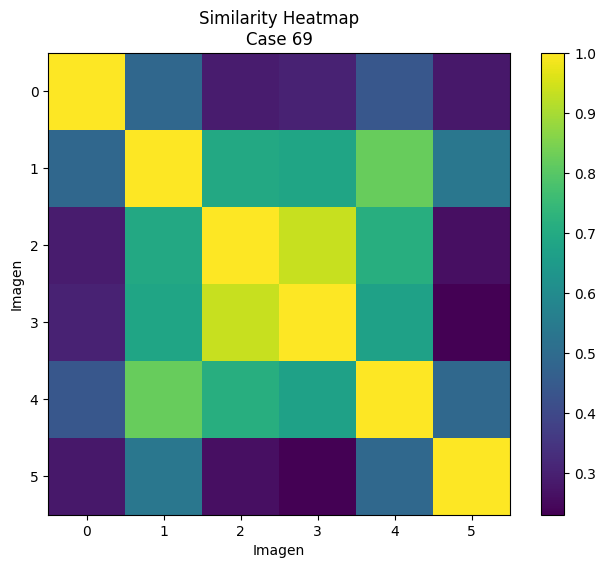

In [38]:
case_index = 79

selected_case = results_df.iloc[case_index]

selected_case_id = selected_case["case_id"]

print(f"Selected Case Index: {case_index}")
print(f"Selected Case ID: {selected_case_id}")
print(f"Expected Status: {selected_case['expected_status']}")
print(f"Predicted Status: {selected_case['predicted_status']}")
print(f"Robust Score: {selected_case['robust_score']:.4f}")

####
matrix = np.array(
    selected_case["pairwise_matrix"]
)

plt.figure(figsize=(8, 6))

plt.imshow(matrix)

plt.colorbar()

plt.title(
    f"Similarity Heatmap\nCase {selected_case_id}"
)

plt.xlabel("Imagen")

plt.ylabel("Imagen")

plt.show()

# Visualización de Imágenes del Caso

A continuación se muestran las imágenes originales utilizadas en el caso seleccionado.

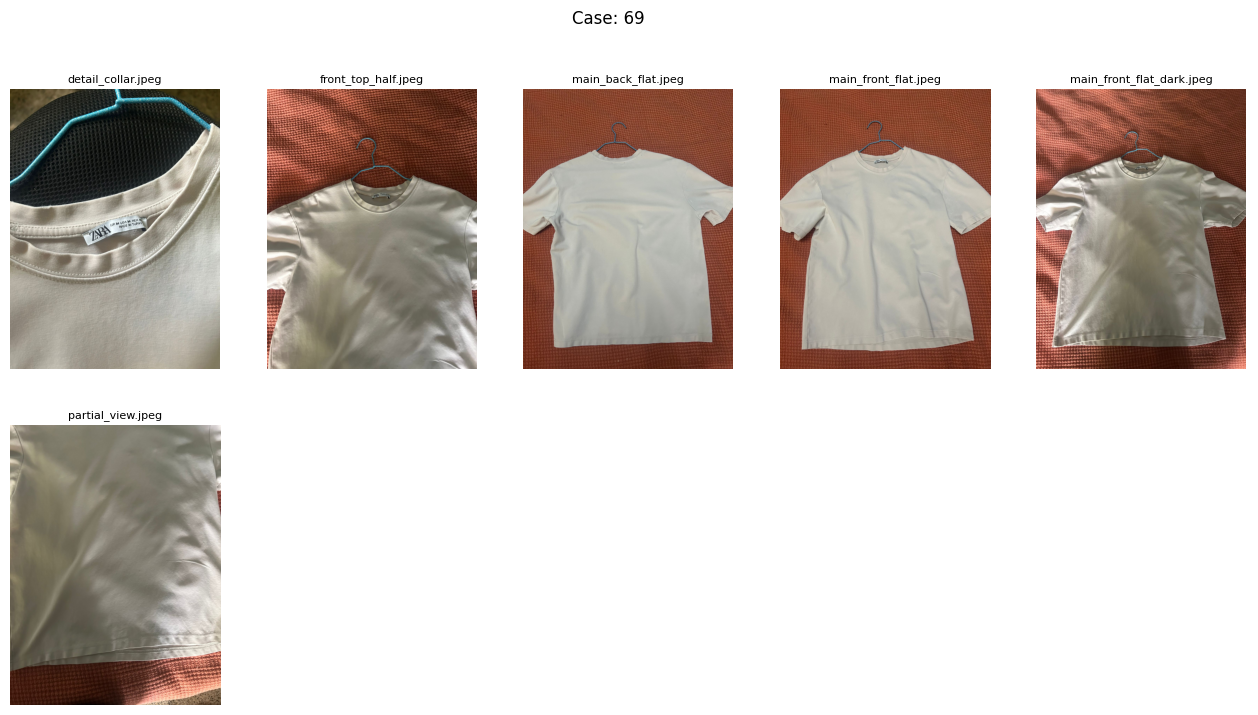

In [39]:
case_path = DATASET_DIR / selected_case_id

image_paths = sorted([
    p for p in case_path.iterdir()
    if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
])

fig, axes = plt.subplots(2, 5, figsize=(16, 8))

axes = axes.flatten()

for ax, img_path in zip(axes, image_paths):

    img = plt.imread(img_path)

    ax.imshow(img)

    ax.set_title(img_path.name, fontsize=8)

    ax.axis("off")

for ax in axes[len(image_paths):]:
    ax.axis("off")

plt.suptitle(
    f"Case: {selected_case_id}"
)

plt.show()

# Visualización de Imágenes Marcadas (`flagged_images`)

Las imágenes identificadas como inconsistentes o sospechosas son resaltadas visualmente.

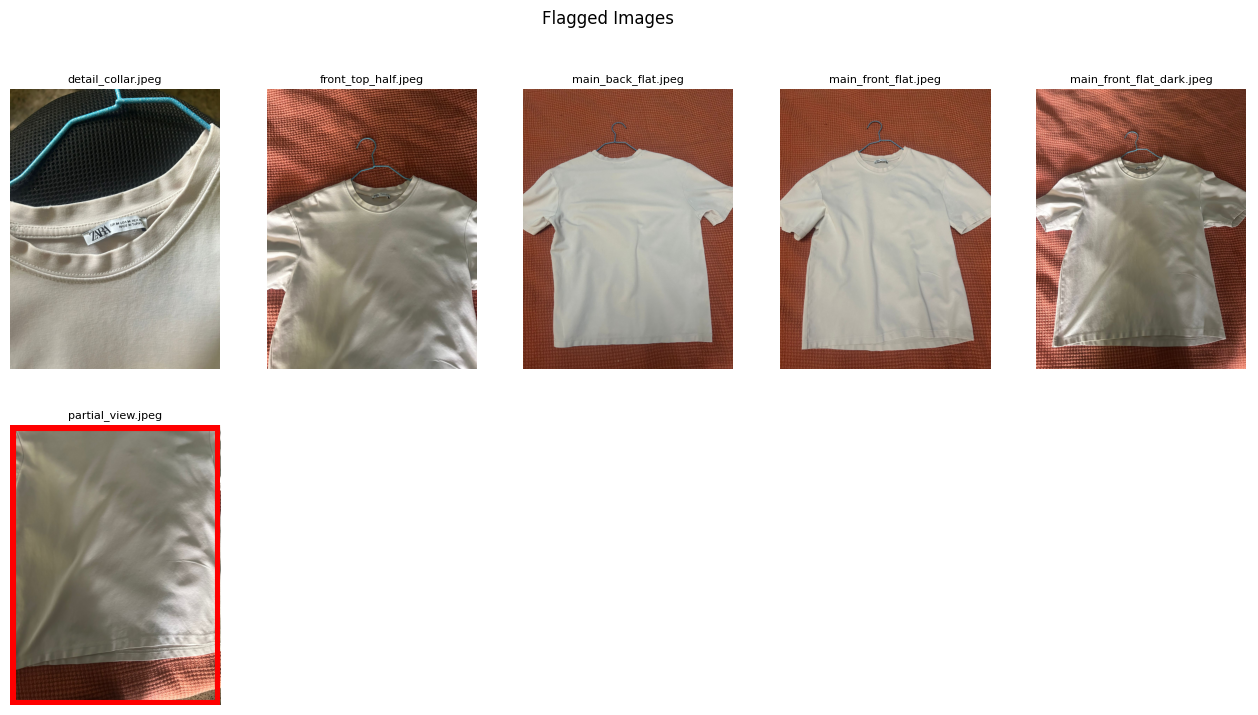

In [40]:
flagged_filenames = []

for item in selected_case["flagged_images"]:

    if isinstance(item, dict):

        filename = item.get("filename")

        if filename:
            flagged_filenames.append(filename)

fig, axes = plt.subplots(2, 5, figsize=(16, 8))

axes = axes.flatten()

for ax, img_path in zip(axes, image_paths):

    img = plt.imread(img_path)

    ax.imshow(img)

    if img_path.name in flagged_filenames:

        rect = patches.Rectangle(
            (0, 0),
            img.shape[1],
            img.shape[0],
            linewidth=8,
            edgecolor="red",
            facecolor="none"
        )

        ax.add_patch(rect)

    ax.set_title(img_path.name, fontsize=8)

    ax.axis("off")

for ax in axes[len(image_paths):]:
    ax.axis("off")

plt.suptitle("Flagged Images")

plt.show()

# Casos con Menor Consistencia

Los siguientes casos corresponden a los menores valores de `robust_consistency_score`.

In [41]:
results_df.sort_values(
    by="robust_score"
).head(10)[[
    "case_id",
    "expected_status",
    "predicted_status",
    "robust_score"
]]

,case_id,expected_status,predicted_status,robust_score
7,107,inconsistent,inconsistent,0.4796
85,75,needs_review,needs_review,0.5719
9,109,inconsistent,inconsistent,0.5823
2,101,inconsistent,inconsistent,0.5846
76,65,consistent,needs_review,0.6096
96,85,needs_review,needs_review,0.6319
94,83,needs_review,needs_review,0.6319
86,76,needs_review,needs_review,0.6330
84,74,needs_review,needs_review,0.6441
89,79,needs_review,needs_review,0.6514


# Casos con Mayor Consistencia

Los siguientes casos presentan los scores de consistencia más altos.

In [42]:
results_df.sort_values(
    by="robust_score",
    ascending=False
).head(10)[[
    "case_id",
    "expected_status",
    "predicted_status",
    "robust_score"
]]

,case_id,expected_status,predicted_status,robust_score
35,25,consistent,consistent,0.9251
50,40,consistent,consistent,0.9193
46,36,consistent,consistent,0.9128
70,6,consistent,consistent,0.8993
52,42,consistent,consistent,0.8949
43,33,consistent,consistent,0.8915
40,30,consistent,consistent,0.8912
53,43,consistent,consistent,0.8890
30,20,consistent,consistent,0.8846
48,39,consistent,consistent,0.8832


# Exportación de Resultados

Finalmente, los resultados consolidados se exportan para futuras evaluaciones y para integrarlos al reporte del proyecto.

In [43]:
results_df.to_csv(
    REPORTS_DIR / "notebook_evaluation_results.csv",
    index=False
)

print("Resultados exportados correctamente.")

Resultados exportados correctamente.
